In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import multiprocessing as mp

import os
import re
import itertools
import pickle
import json
import datetime
import urllib.parse

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from collections import defaultdict
from multiprocess import Pool

# Load interaction data

In [2]:
df = pd.read_excel(f"../outputs/final_outputs/triples.xlsx").drop("Unnamed: 0", axis=1)
df_isco = pd.read_excel("../outputs/final_outputs/triples_ISCO_esco.xlsx")
df_isco_cv = pd.read_excel("../outputs/final_outputs/cv_esco.xlsx")
iscos = pd.read_csv("../pipeline/data_files/isco.csv", encoding="cp850")
df_bridges = pd.read_excel("../outputs/final_outputs/bridges.xlsx")
df_CVs = pd.read_excel("../outputs/final_outputs/cv.xlsx")

In [4]:
df_int = pd.read_csv("../../dataset/final_dataset/contacted_anon.csv")

# Only keep vacancies with at least 15 interactions
relevant_vacancies = df_int["cvid"].value_counts()[df_int["cvid"].value_counts() >= 15].index

# Filter to only relevant vacancies
df_int = df_int[df_int["cvid"].isin(relevant_vacancies.values)][["humanjobid", "response", "cvid"]].fillna(0)

### TODO: TRY WHAT HAPPENS WHEN WE ONLY USE ACTUAL 1S
strict = True

if strict:
    df_int["response"] = df_int["response"].apply(lambda x: 1 if "ok" in str(x) else 0)
else:
    df_int["response"] = df_int["response"].apply(lambda x: x if x == 0 else 1)

non_zero = df_int.groupby("cvid")["response"].sum() > 0
non_zero = set(non_zero[non_zero == True].index)
len(non_zero), len(df_int.groupby("cvid"))

df_graphs = df_int[df_int["cvid"].isin(non_zero)]

In [5]:
def clean_entity(entity):
    """Normalizes a string to lowercase, replaces spaces/hyphens with underscores, and strips symbols."""
    # Return as-is if the entity is a float/int (like 28.0)
    if not isinstance(entity, str):
        return entity
        
    # Lowercase the string
    e = entity.lower()
    
    # Remove specific symbols like '&' entirely before replacing other chars
    e = e.replace('&', '')
    
    # Replace anything that isn't a letter, number, or underscore with a space
    e = re.sub(r'[^a-z0-9_]', ' ', e)
    
    # Replace multiple spaces with a single underscore, and strip leading/trailing spaces
    e = re.sub(r'\s+', '_', e.strip())
    
    # Remove leading or trailing underscores just in case
    e = e.strip('_')
    
    return e

def clean_triples(triples):
    """Applies the cleaning function to the subject and object of each triple."""
    cleaned = []
    for sub, pred, obj in triples:
        cleaned.append((clean_entity(sub), pred, clean_entity(obj)))
    return cleaned

In [38]:
# 1. OUTERMOST LOOP: ISCO
for isco in [True, False]:
    print(f"\n{'='*50}\nSTARTING DATASET GENERATION: ISCO = {isco}\n{'='*50}")
    
    # Reset dictionaries for this specific ISCO dataset
    full_graphs = defaultdict(list)
    connected = defaultdict(lambda: defaultdict(list))
    
    # 2. MODEL & PROMPT LOOPS
    for model in ["qwen", "gemma", "llama"]:
        for prompt in ["structured", "semi-structured", "unstructured"]:
            
            print(f"\n--- Processing: Model={model}, Prompt={prompt}, ISCO={isco} ---")
            
            # Track metrics just for this specific model/prompt combination
            loop_metrics = defaultdict(list)
            
            for row in tqdm(df_int.iterrows(), total=len(df_int), desc=f"Building {model} {prompt}"):
                G = nx.DiGraph()
                
                # Extract Triples
                triples_vacancy = df[df["id"] == row[1][0]][f"triples_{model}_{prompt}"].values[0]
                triples_cv = df_CVs[df_CVs["id"] == row[1][2]]["CV_triples"].values[0]
                triples_bridges = df_bridges[(df_bridges["humanjobid"] == row[1][0]) & 
                    (df_bridges["cvid"] == row[1][2])][f"bridges_{model}_{prompt}"].values[0]

                if triples_bridges == "[]":
                    continue

                # Handle ISCO logic based on the current loop state
                if isco:
                    triples_isco = df_isco[df_isco["humanjobid"] == row[1][0]][f"ISCO {model} {prompt}"].values[0]
                    triples_isco_cv = df_isco_cv[df_isco_cv["candidate"] == row[1][2]][f"ISCO cv {model}"].values[0]

                try:            
                    if isco:
                        all_edges = eval(triples_vacancy) + eval(triples_cv) + eval(triples_bridges) + \
                                    eval(triples_isco) + eval(triples_isco_cv)
                    else:
                        all_edges = eval(triples_vacancy) + eval(triples_cv) + eval(triples_bridges)
                except Exception:
                    continue
                    
                all_edges = clean_triples(all_edges)
                
                for s, p, o in all_edges:
                    G.add_edge(s, o, edge_type=p)

                # --- TOPOLOGICAL METRICS SETUP ---
                metrics = {
                    "num_nodes": G.number_of_nodes(),
                    "num_edges": G.number_of_edges(),
                    "density": 0.0,
                    "avg_degree": 0.0,
                    "avg_clustering": 0.0,
                    "path_exists": False,
                    "shortest_path_length": -1
                }

                try:
                    vacancy_node = clean_triples(eval(triples_vacancy))[0][0]
                    cv_node = clean_triples(eval(triples_cv))[0][0]
                    undirected_G = G.to_undirected()
                    
                    G_safe = nx.Graph(undirected_G) # Flattens multi-edges
                    v_count = G_safe.number_of_nodes()
                    e_count = G_safe.number_of_edges()
                    
                    if v_count > 1:
                        metrics["density"] = nx.density(G_safe)
                        metrics["avg_degree"] = (2.0 * e_count) / v_count
                        metrics["avg_clustering"] = nx.average_clustering(G_safe)

                    if vacancy_node in undirected_G and cv_node in undirected_G:
                        has_path = nx.has_path(undirected_G, source=vacancy_node, target=cv_node)
                        metrics["path_exists"] = has_path
                        connected[model][prompt].append(has_path)
                        
                        if has_path:
                            metrics["shortest_path_length"] = nx.shortest_path_length(
                                undirected_G, source=vacancy_node, target=cv_node
                            )
                    else:
                        connected[model][prompt].append(False)
                        
                except Exception:
                    connected[model][prompt].append(False)
                    
                # --- APPEND TO DICTIONARIES ---
                full_graphs["isco"].append(isco)
                full_graphs["model"].append(model)
                full_graphs["prompt"].append(prompt)
                full_graphs["vacancy"].append(row[1][0])
                full_graphs["cvid"].append(row[1][2])
                full_graphs["response"].append(row[1][1])
                
                undirected_G.add_edge(cv_node, vacancy_node)
                full_graphs["graph"].append(nx.node_link_data(undirected_G))
                
                for key, val in metrics.items():
                    full_graphs[key].append(val)
                    loop_metrics[key].append(val)
                    
            # --- PRINT METRICS AFTER EACH COMBINATION LOOP ---
            valid_paths = [p for p in loop_metrics["path_exists"]]
            valid_lengths = [l for l in loop_metrics["shortest_path_length"] if l != -1]
            
            path_ratio = np.mean(valid_paths) if valid_paths else 0.0
            avg_len = np.mean(valid_lengths) if valid_lengths else 0.0
            avg_nodes = np.mean(loop_metrics["num_nodes"]) if loop_metrics["num_nodes"] else 0.0
            avg_edges = np.mean(loop_metrics["num_edges"]) if loop_metrics["num_edges"] else 0.0
            avg_density = np.mean(loop_metrics["density"]) if loop_metrics["density"] else 0.0
            avg_clustering = np.mean(loop_metrics["avg_clustering"]) if loop_metrics["avg_clustering"] else 0.0
            
            print(f"  > Valid Paths:    {path_ratio:.2%}")
            print(f"  > Avg Path Len:   {avg_len:.2f} hops")
            print(f"  > Avg Graph Size: {avg_nodes:.1f} nodes, {avg_edges:.1f} edges")
            print(f"  > Avg Density:    {avg_density:.4f}")
            print(f"  > Avg Clustering: {avg_clustering:.4f}\n")

    # --- FINAL SERIALIZATION & SAVING (PER ISCO TOGGLE) ---
    print(f"All models/prompts complete for ISCO={isco}. Serializing graphs...")
    df_final = pd.DataFrame(full_graphs) 
    df_final["graph"] = df_final['graph'].apply(json.dumps)
    
    s = "strict" if strict else "easy"
    
    if isco:
        save_path = f"subgraphs_isco_no_inference_{s}.parquet"
    else:
        save_path = f"subgraphs_no_inference_{s}.parquet"
        
    df_final.to_parquet(save_path)
    print(f"Saved successfully to: {save_path}\n")

print("Finished processing all ISCO combinations!")


STARTING DATASET GENERATION: ISCO = True

--- Processing: Model=qwen, Prompt=structured, ISCO=True ---


Building qwen structured:   0%|          | 0/24057 [00:00<?, ?it/s]

C:\Users\roans\AppData\Local\Temp\ipykernel_2188\4169285081.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  triples_vacancy = df[df["id"] == row[1][0]][f"triples_{model}_{prompt}"].values[0]
C:\Users\roans\AppData\Local\Temp\ipykernel_2188\4169285081.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  triples_cv = df_CVs[df_CVs["id"] == row[1][2]]["CV_triples"].values[0]
C:\Users\roans\AppData\Local\Temp\ipykernel_2188\4169285081.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavio

  > Valid Paths:    98.05%
  > Avg Path Len:   2.15 hops
  > Avg Graph Size: 49.9 nodes, 57.2 edges
  > Avg Density:    0.0512
  > Avg Clustering: 0.0417


--- Processing: Model=qwen, Prompt=semi-structured, ISCO=True ---


Building qwen semi-structured:   0%|          | 0/24057 [00:00<?, ?it/s]

...

  > Valid Paths:    93.49%
  > Avg Path Len:   2.03 hops
  > Avg Graph Size: 58.6 nodes, 90.2 edges
  > Avg Density:    0.0591
  > Avg Clustering: 0.1225


--- Processing: Model=llama, Prompt=semi-structured, ISCO=False ---


Building llama semi-structured:   0%|          | 0/24057 [00:00<?, ?it/s]

  > Valid Paths:    93.60%
  > Avg Path Len:   2.10 hops
  > Avg Graph Size: 59.4 nodes, 90.6 edges
  > Avg Density:    0.0574
  > Avg Clustering: 0.1205


--- Processing: Model=llama, Prompt=unstructured, ISCO=False ---


Building llama unstructured:   0%|          | 0/24057 [00:00<?, ?it/s]

  > Valid Paths:    70.28%
  > Avg Path Len:   2.83 hops
  > Avg Graph Size: 64.9 nodes, 103.2 edges
  > Avg Density:    0.0539
  > Avg Clustering: 0.0943

All models/prompts complete for ISCO=False. Serializing graphs...
Saved successfully to: subgraphs_no_inference_strict.parquet

Finished processing all ISCO combinations!


In [14]:
def plot_clean_graph(G):
    plt.figure(figsize=(10, 8))
    
    # 1. REMOVE SELF-LOOPS FROM THE PLOT ONLY
    # We don't want to see them, even if they exist in the data
    display_G = G.copy()
    display_G.remove_edges_from(nx.selfloop_edges(display_G))
    
    # 2. POSITIONAL LAYOUT
    # Spring layout is good, but 'kamada_kawai' is better for seeing paths
    pos = nx.kamada_kawai_layout(display_G)
    
    # 3. DRAW
    nx.draw_networkx_nodes(display_G, pos, node_size=500, node_color='#1f78b4')
    nx.draw_networkx_edges(display_G, pos, alpha=0.5, edge_color='gray', arrows=True)
    
    # 4. CLEAN LABELS
    # Shorten the long jie: labels so they don't overlap
    labels = {n: str(n).replace("jie:", "").replace("_jie_", "").split('/')[-1][:20] for n in display_G.nodes()}
    nx.draw_networkx_labels(display_G, pos, labels, font_size=8)
    
    plt.axis('off')
    plt.show()

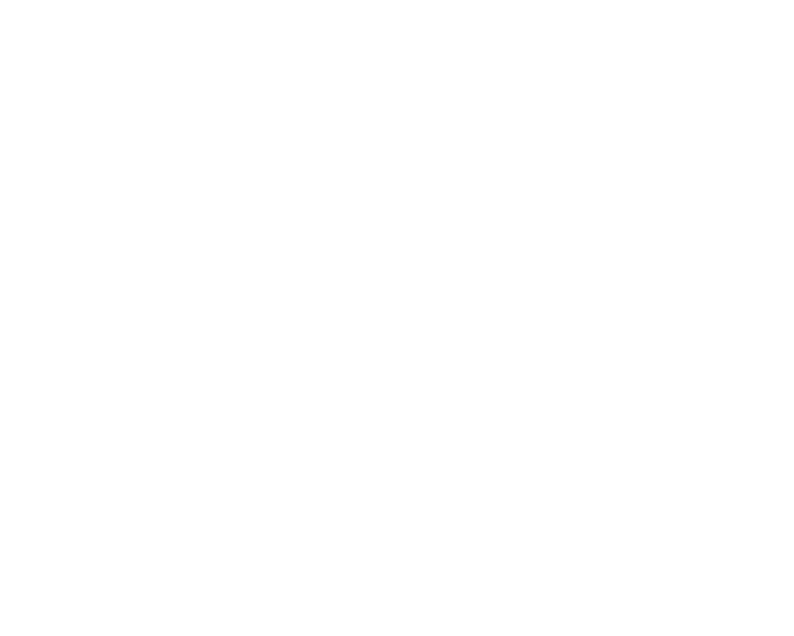

In [15]:
plot_clean_graph(G)